# Glovo E-Commerce Delivery Data AnalysisEnd-to-end analysis of Glovo order data — data quality checks, exploratory data analysis, and predictive modeling (regression + classification) for order value and delivery status.

## 1. Data Loading & Overview

In [2]:
import pandas as pd 

In [3]:
df = pd.read_csv(r"C:\Users\Dell~latitude\Downloads\orders_details.csv")

In [4]:
df

,Unnamed: 0,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status_x,order_total,payment_method,number_product,...,registration_date,customer_segment,total_orders,avg_order_value,delivery_partner_id,promised_time,actual_time,delivery_time_minutes,distance_km,delivery_status_y
0,0,2850500678,97145527,2024-03-29 01:27:15,2024-03-29 01:46:15,2024-03-29 01:59:15,Slightly Delayed,4817.54,Cash,6,...,2023-08-27,Premium,11,1298.98,32423,2024-03-29 01:46:15,2024-03-29 01:59:15,13.0,4.84,Slightly Delayed
1,1,7171106490,45835229,2023-08-17 15:46:27,2023-08-17 15:59:27,2023-08-17 15:57:27,On Time,922.44,Cash,1,...,2025-07-16,Regular,13,1691.43,2312,2023-08-17 15:59:27,2023-08-17 15:57:27,-2.0,1.49,On Time
2,2,3829771237,25578646,2023-11-23 23:46:22,2023-11-24 00:05:22,2023-11-24 00:08:22,On Time,4154.91,Cash,8,...,2024-09-25,Inactive,8,1662.66,87568,2023-11-24 00:05:22,2023-11-24 00:08:22,3.0,4.08,On Time
3,3,459643984,68711385,2025-07-17 17:33:23,2025-07-17 17:51:23,2025-07-17 17:52:23,On Time,2682.11,Wallet,5,...,2024-11-29,Regular,1,1615.63,96765,2025-07-17 17:51:23,2025-07-17 17:52:23,1.0,3.21,On Time
4,4,1316777473,52002897,2023-12-16 13:15:48,2023-12-16 13:34:48,2023-12-16 14:01:48,Significantly Delayed,1861.67,Cash,3,...,2023-10-04,New,17,456.76,43840,2023-12-16 13:34:48,2023-12-16 14:01:48,27.0,0.95,Significantly Delayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49995,8723712295,47886757,2025-04-20 07:11:21,2025-04-20 07:24:21,2025-04-20 07:43:21,Significantly Delayed,2766.50,Cash,7,...,2023-03-10,New,3,1309.63,86759,2025-04-20 07:24:21,2025-04-20 07:43:21,19.0,4.11,Significantly Delayed
49996,49996,6391097220,37267435,2024-04-15 00:08:27,2024-04-15 00:26:27,2024-04-15 00:28:27,On Time,495.66,Card,1,...,2025-09-13,Regular,3,734.08,35634,2024-04-15 00:26:27,2024-04-15 00:28:27,2.0,4.58,On Time
49997,49997,8979901439,84420420,2025-04-26 17:02:03,2025-04-26 17:19:03,2025-04-26 17:14:03,On Time,132.28,Wallet,1,...,2023-01-09,Inactive,2,1515.50,83269,2025-04-26 17:19:03,2025-04-26 17:14:03,-5.0,1.57,On Time
49998,49998,6937038206,86370235,2025-11-18 12:17:36,2025-11-18 12:32:36,2025-11-18 12:27:36,On Time,1739.75,Card,5,...,2023-11-14,New,10,1402.31,48310,2025-11-18 12:32:36,2025-11-18 12:27:36,-5.0,3.20,On Time


In [5]:
df.head()

,Unnamed: 0,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status_x,order_total,payment_method,number_product,...,registration_date,customer_segment,total_orders,avg_order_value,delivery_partner_id,promised_time,actual_time,delivery_time_minutes,distance_km,delivery_status_y
0,0,2850500678,97145527,2024-03-29 01:27:15,2024-03-29 01:46:15,2024-03-29 01:59:15,Slightly Delayed,4817.54,Cash,6,...,2023-08-27,Premium,11,1298.98,32423,2024-03-29 01:46:15,2024-03-29 01:59:15,13.0,4.84,Slightly Delayed
1,1,7171106490,45835229,2023-08-17 15:46:27,2023-08-17 15:59:27,2023-08-17 15:57:27,On Time,922.44,Cash,1,...,2025-07-16,Regular,13,1691.43,2312,2023-08-17 15:59:27,2023-08-17 15:57:27,-2.0,1.49,On Time
2,2,3829771237,25578646,2023-11-23 23:46:22,2023-11-24 00:05:22,2023-11-24 00:08:22,On Time,4154.91,Cash,8,...,2024-09-25,Inactive,8,1662.66,87568,2023-11-24 00:05:22,2023-11-24 00:08:22,3.0,4.08,On Time
3,3,459643984,68711385,2025-07-17 17:33:23,2025-07-17 17:51:23,2025-07-17 17:52:23,On Time,2682.11,Wallet,5,...,2024-11-29,Regular,1,1615.63,96765,2025-07-17 17:51:23,2025-07-17 17:52:23,1.0,3.21,On Time
4,4,1316777473,52002897,2023-12-16 13:15:48,2023-12-16 13:34:48,2023-12-16 14:01:48,Significantly Delayed,1861.67,Cash,3,...,2023-10-04,New,17,456.76,43840,2023-12-16 13:34:48,2023-12-16 14:01:48,27.0,0.95,Significantly Delayed


In [6]:
df.tail()

,Unnamed: 0,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status_x,order_total,payment_method,number_product,...,registration_date,customer_segment,total_orders,avg_order_value,delivery_partner_id,promised_time,actual_time,delivery_time_minutes,distance_km,delivery_status_y
49995,49995,8723712295,47886757,2025-04-20 07:11:21,2025-04-20 07:24:21,2025-04-20 07:43:21,Significantly Delayed,2766.50,Cash,7,...,2023-03-10,New,3,1309.63,86759,2025-04-20 07:24:21,2025-04-20 07:43:21,19.0,4.11,Significantly Delayed
49996,49996,6391097220,37267435,2024-04-15 00:08:27,2024-04-15 00:26:27,2024-04-15 00:28:27,On Time,495.66,Card,1,...,2025-09-13,Regular,3,734.08,35634,2024-04-15 00:26:27,2024-04-15 00:28:27,2.0,4.58,On Time
49997,49997,8979901439,84420420,2025-04-26 17:02:03,2025-04-26 17:19:03,2025-04-26 17:14:03,On Time,132.28,Wallet,1,...,2023-01-09,Inactive,2,1515.50,83269,2025-04-26 17:19:03,2025-04-26 17:14:03,-5.0,1.57,On Time
49998,49998,6937038206,86370235,2025-11-18 12:17:36,2025-11-18 12:32:36,2025-11-18 12:27:36,On Time,1739.75,Card,5,...,2023-11-14,New,10,1402.31,48310,2025-11-18 12:32:36,2025-11-18 12:27:36,-5.0,3.20,On Time
49999,49999,338807154,34155018,2023-09-06 06:39:29,2023-09-06 06:52:29,2023-09-06 06:55:29,On Time,3997.77,Wallet,7,...,2024-02-09,Regular,14,1153.73,84043,2023-09-06 06:52:29,2023-09-06 06:55:29,3.0,2.99,On Time


In [7]:
df.shape

(50000, 30)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              50000 non-null  int64  
 1   order_id                50000 non-null  int64  
 2   customer_id             50000 non-null  int64  
 3   order_date              50000 non-null  object 
 4   promised_delivery_time  50000 non-null  object 
 5   actual_delivery_time    50000 non-null  object 
 6   delivery_status_x       50000 non-null  object 
 7   order_total             50000 non-null  float64
 8   payment_method          50000 non-null  object 
 9   number_product          50000 non-null  int64  
 10  total_Quantity          50000 non-null  int64  
 11  total_profit            50000 non-null  float64
 12  feedback_id             50000 non-null  int64  
 13  rating                  50000 non-null  int64  
 14  feedback_category       50000 non-null

In [9]:
df.describe()

,Unnamed: 0,order_id,customer_id,order_total,number_product,total_Quantity,total_profit,feedback_id,rating,pincode,total_orders,avg_order_value,delivery_partner_id,delivery_time_minutes,distance_km
count,50000.000000,5.000000e+04,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,24999.500000,5.017059e+09,4.962185e+07,2324.709157,4.504760,8.997080,688.584981,5.013838e+06,4.051080,498880.783600,10.532820,1104.842240,49992.429760,4.367440,2.748716
std,14433.901067,2.886026e+09,2.883263e+07,1323.866041,2.296929,4.905934,403.746583,2.884739e+06,0.956498,288207.151828,5.794811,518.407866,28868.058468,8.119967,1.298085
min,0.000000,1.645150e+05,2.650000e+02,21.320000,1.000000,1.000000,4.520000,6.000000e+01,1.000000,15.000000,1.000000,200.000000,0.000000,-5.000000,0.500000
25%,12499.750000,2.515862e+09,2.464692e+07,1218.132500,2.000000,5.000000,351.339125,2.512090e+06,4.000000,252877.000000,6.000000,662.192500,25004.500000,-2.000000,1.630000
50%,24999.500000,5.026781e+09,4.936333e+07,2243.440000,4.000000,9.000000,659.115000,5.045637e+06,4.000000,499527.000000,10.000000,1106.040000,50083.500000,2.000000,2.750000
75%,37499.250000,7.526527e+09,7.441981e+07,3332.762500,7.000000,13.000000,986.437875,7.491792e+06,5.000000,746107.000000,16.000000,1551.815000,74902.250000,8.000000,3.870000
max,49999.000000,9.999669e+09,9.999347e+07,6831.530000,8.000000,24.000000,2225.255000,9.999934e+06,5.000000,999978.000000,20.000000,1999.950000,99999.000000,30.000000,5.000000


In [10]:
df.describe(include ='all')

,Unnamed: 0,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status_x,order_total,payment_method,number_product,...,registration_date,customer_segment,total_orders,avg_order_value,delivery_partner_id,promised_time,actual_time,delivery_time_minutes,distance_km,delivery_status_y
count,50000.000000,5.000000e+04,5.000000e+04,50000,50000,50000,50000,50000.000000,50000,50000.000000,...,50000,50000,50000.000000,50000.000000,50000.000000,50000,50000,50000.000000,50000.000000,50000
unique,NaN,NaN,NaN,49984,49990,49977,3,NaN,4,NaN,...,1095,4,NaN,NaN,NaN,49990,49977,NaN,NaN,3
top,NaN,NaN,NaN,2025-01-27 04:25:57,2024-04-27 04:01:27,2025-01-27 04:41:57,On Time,NaN,Wallet,NaN,...,2025-02-05,Inactive,NaN,NaN,NaN,2024-04-27 04:01:27,2025-01-27 04:41:57,NaN,NaN,On Time
freq,NaN,NaN,NaN,2,2,2,35116,NaN,12674,NaN,...,105,12708,NaN,NaN,NaN,2,2,NaN,NaN,35116
mean,24999.500000,5.017059e+09,4.962185e+07,NaN,NaN,NaN,NaN,2324.709157,NaN,4.504760,...,NaN,NaN,10.532820,1104.842240,49992.429760,NaN,NaN,4.367440,2.748716,NaN
std,14433.901067,2.886026e+09,2.883263e+07,NaN,NaN,NaN,NaN,1323.866041,NaN,2.296929,...,NaN,NaN,5.794811,518.407866,28868.058468,NaN,NaN,8.119967,1.298085,NaN
min,0.000000,1.645150e+05,2.650000e+02,NaN,NaN,NaN,NaN,21.320000,NaN,1.000000,...,NaN,NaN,1.000000,200.000000,0.000000,NaN,NaN,-5.000000,0.500000,NaN
25%,12499.750000,2.515862e+09,2.464692e+07,NaN,NaN,NaN,NaN,1218.132500,NaN,2.000000,...,NaN,NaN,6.000000,662.192500,25004.500000,NaN,NaN,-2.000000,1.630000,NaN
50%,24999.500000,5.026781e+09,4.936333e+07,NaN,NaN,NaN,NaN,2243.440000,NaN,4.000000,...,NaN,NaN,10.000000,1106.040000,50083.500000,NaN,NaN,2.000000,2.750000,NaN
75%,37499.250000,7.526527e+09,7.441981e+07,NaN,NaN,NaN,NaN,3332.762500,NaN,7.000000,...,NaN,NaN,16.000000,1551.815000,74902.250000,NaN,NaN,8.000000,3.870000,NaN


## 2. Data Quality Check (Missing Values)

In [11]:
df.isnull()

,Unnamed: 0,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status_x,order_total,payment_method,number_product,...,registration_date,customer_segment,total_orders,avg_order_value,delivery_partner_id,promised_time,actual_time,delivery_time_minutes,distance_km,delivery_status_y
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
49996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
49997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
49998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [12]:
df.isnull().sum()

Unnamed: 0                0
order_id                  0
customer_id               0
order_date                0
promised_delivery_time    0
actual_delivery_time      0
delivery_status_x         0
order_total               0
payment_method            0
number_product            0
total_Quantity            0
total_profit              0
feedback_id               0
rating                    0
feedback_category         0
sentiment                 0
feedback_date             0
customer_name             0
area                      0
pincode                   0
registration_date         0
customer_segment          0
total_orders              0
avg_order_value           0
delivery_partner_id       0
promised_time             0
actual_time               0
delivery_time_minutes     0
distance_km               0
delivery_status_y         0
dtype: int64

In [13]:
df.isnull().sum().sum()

np.int64(0)

In [14]:
df.isnull().mean()*100

Unnamed: 0                0.0
order_id                  0.0
customer_id               0.0
order_date                0.0
promised_delivery_time    0.0
actual_delivery_time      0.0
delivery_status_x         0.0
order_total               0.0
payment_method            0.0
number_product            0.0
total_Quantity            0.0
total_profit              0.0
feedback_id               0.0
rating                    0.0
feedback_category         0.0
sentiment                 0.0
feedback_date             0.0
customer_name             0.0
area                      0.0
pincode                   0.0
registration_date         0.0
customer_segment          0.0
total_orders              0.0
avg_order_value           0.0
delivery_partner_id       0.0
promised_time             0.0
actual_time               0.0
delivery_time_minutes     0.0
distance_km               0.0
delivery_status_y         0.0
dtype: float64

In [15]:
df.isnull().any()

Unnamed: 0                False
order_id                  False
customer_id               False
order_date                False
promised_delivery_time    False
actual_delivery_time      False
delivery_status_x         False
order_total               False
payment_method            False
number_product            False
total_Quantity            False
total_profit              False
feedback_id               False
rating                    False
feedback_category         False
sentiment                 False
feedback_date             False
customer_name             False
area                      False
pincode                   False
registration_date         False
customer_segment          False
total_orders              False
avg_order_value           False
delivery_partner_id       False
promised_time             False
actual_time               False
delivery_time_minutes     False
distance_km               False
delivery_status_y         False
dtype: bool

## 3. Exploratory Data Analysis & Visualization

Count Plot / Bar Graph

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt 

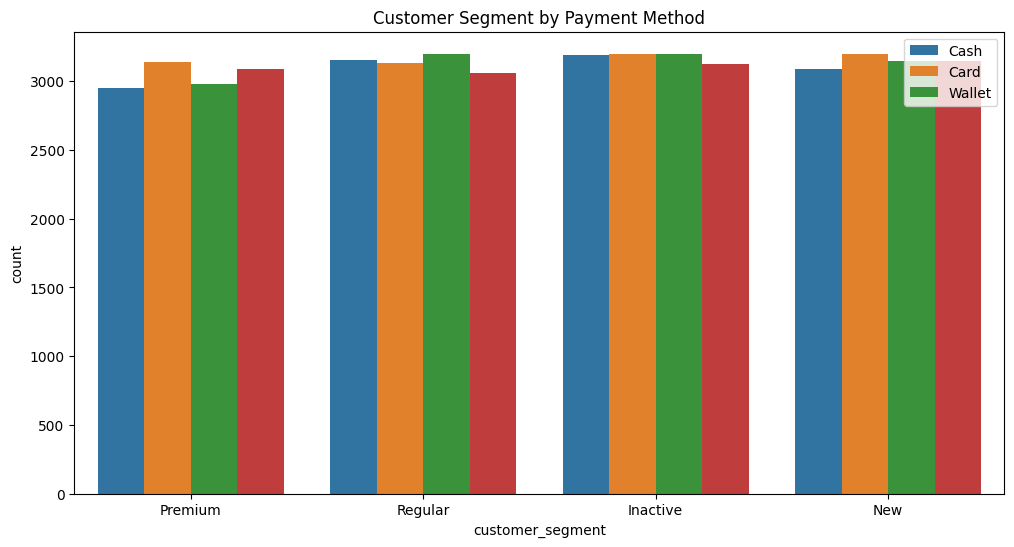

In [17]:
plt.figure(figsize=(12, 6))
sns.countplot(x="customer_segment", hue="payment_method", data=df)
plt.title("Customer Segment by Payment Method")
plt.legend(labels=["Cash", "Card", "Wallet"])
plt.show()

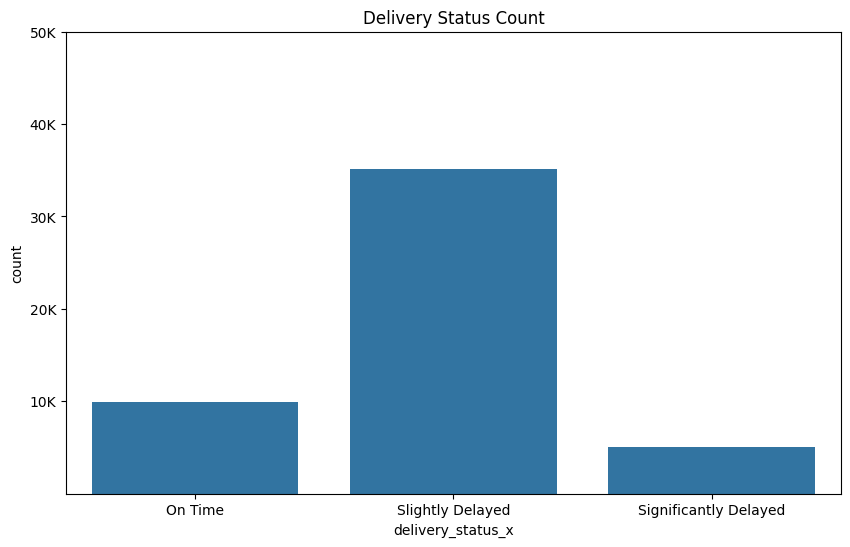

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(x="delivery_status_x", data=df)
plt.title("Delivery Status Count")
plt.xticks([0, 1, 2], ["On Time", "Slightly Delayed", "Significantly Delayed"])
plt.yticks([10000, 20000, 30000, 40000, 50000], ["10K", "20K", "30K", "40K", "50K"])
plt.show()

*Histogram*

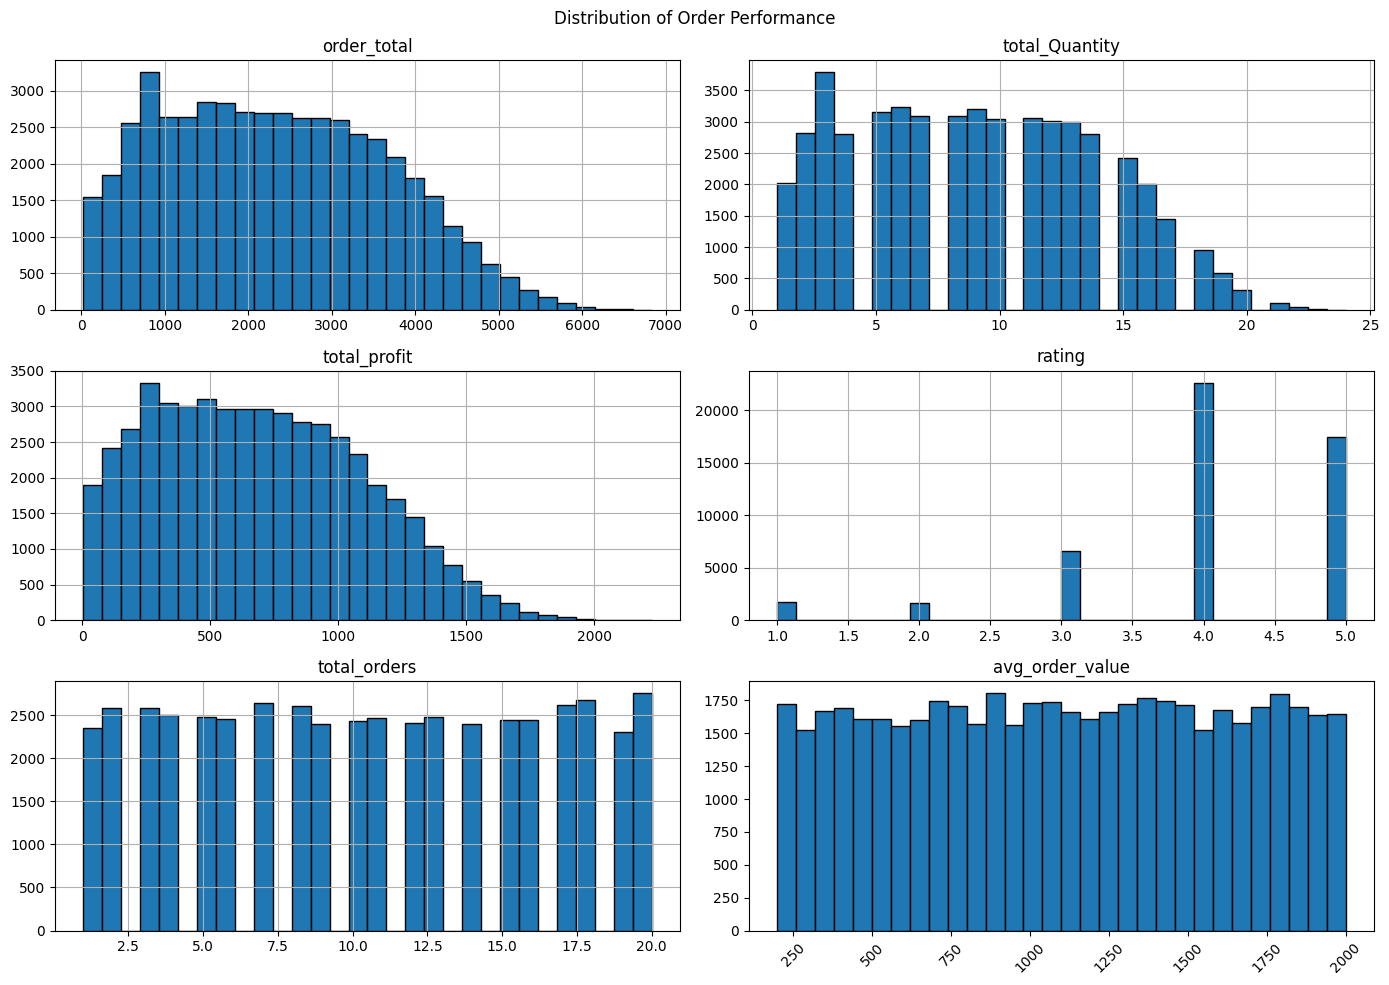

In [19]:
df[['order_total', 'total_Quantity', 'total_profit', 'rating', 'total_orders', 'avg_order_value']].hist(bins=30, figsize=(14, 10), edgecolor='black')
plt.grid(False)
plt.xticks(rotation=45)
plt.suptitle("Distribution of Order Performance")
plt.tight_layout()
plt.show()

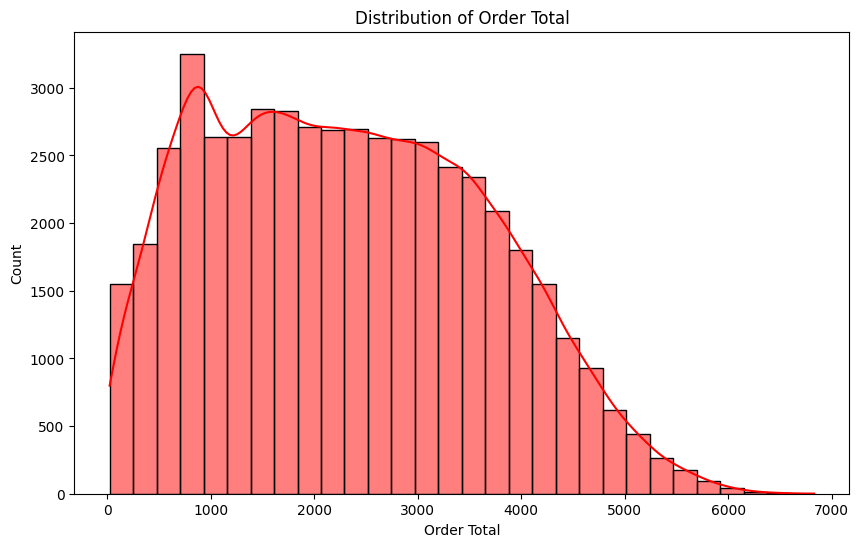

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(df['order_total'], kde=True, color='red', bins=30)
plt.title('Distribution of Order Total')
plt.xlabel('Order Total')
plt.ylabel('Count')
plt.show()

Box Plot

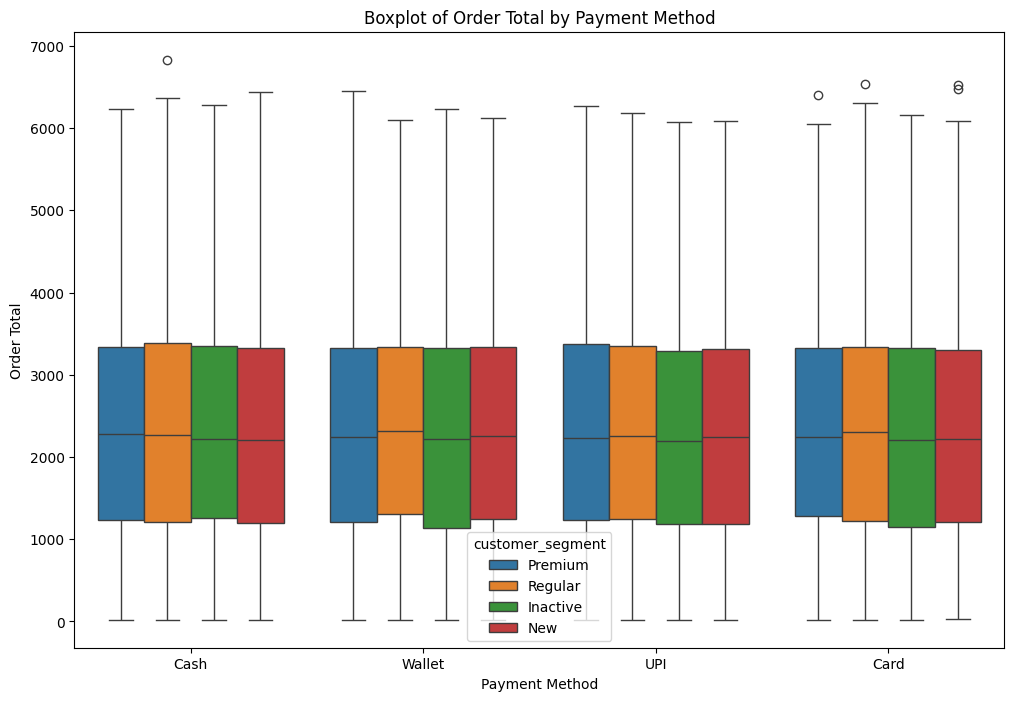

In [21]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='payment_method', y='order_total', hue='customer_segment')
plt.title('Boxplot of Order Total by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Order Total')
plt.show()

Heatmap

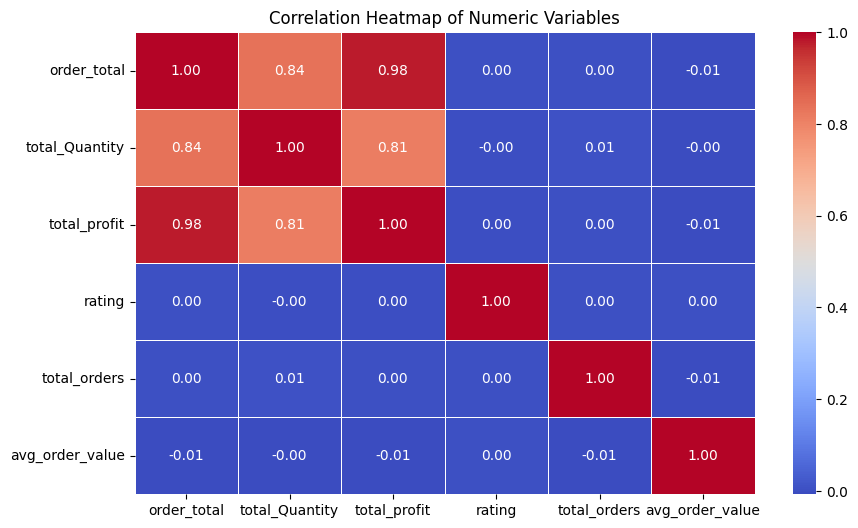

In [22]:
plt.figure(figsize=(10, 6))
corr_matrix = df[['order_total', 'total_Quantity', 'total_profit', 'rating', 'total_orders', 'avg_order_value']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

## 4. Regression ModelingPredicting `order_total` from other order attributes (feature set excludes the target to avoid data leakage).

In [23]:
# Linear Regression - predict order_total
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
X = df[["total_Quantity", "total_profit", "rating", "total_orders", "avg_order_value"]]
y = df["order_total"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("\nCoefficients:\n", model.coef_)
print("\nIntercept:", model.intercept_)

## 5. Classification ModelingPredicting `delivery_status_x` (On Time / Slightly Delayed / Significantly Delayed) using multiple classifiers.

Logistic Regression

In [31]:
# Logistic Regression - predict delivery_status_x
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [32]:
label_encoder = LabelEncoder()

In [33]:
# turn delivery status into numbers so the model can use it
df['delivery_status_x'] = label_encoder.fit_transform(df['delivery_status_x'])

In [34]:
features = ['order_total', 'total_Quantity', 'total_profit', 'rating', 'total_orders', 'avg_order_value']
X = df[features]
y = df['delivery_status_x']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [36]:
log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X_train, y_train)

C:\Users\Dell~Latitude\Desktop\Programming\lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [37]:
y_pred = log_reg.predict(X_test)

In [38]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

In [39]:
print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

Accuracy: 0.8666

Confusion Matrix:
 [[10499     0     0]
 [    0  1036   539]
 [ 1462     0  1464]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93     10499
           1       1.00      0.66      0.79      1575
           2       0.73      0.50      0.59      2926

    accuracy                           0.87     15000
   macro avg       0.87      0.72      0.77     15000
weighted avg       0.86      0.87      0.85     15000



In [40]:
# KNN Classifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings

In [41]:
warnings.filterwarnings('ignore')

X = df[["order_total", "total_Quantity", "total_profit", "rating", "total_orders", "avg_order_value"]]

In [42]:
y = df["delivery_status_x"]

In [43]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
knn_classifier = KNeighborsClassifier(n_neighbors=5)

In [46]:
knn_classifier.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [47]:
y_pred = knn_classifier.predict(X_test)

In [48]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

In [49]:
print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

Accuracy: 0.663

Confusion Matrix:
 [[6502  107  401]
 [ 992   19   54]
 [1793   23  109]]

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.93      0.80      7010
           1       0.13      0.02      0.03      1065
           2       0.19      0.06      0.09      1925

    accuracy                           0.66     10000
   macro avg       0.34      0.33      0.31     10000
weighted avg       0.54      0.66      0.58     10000



In [ ]:
# Support Vector Classifier
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')

In [51]:
X = df[["order_total", "total_Quantity", "total_profit", "rating", "total_orders", "avg_order_value"]]
y = df["delivery_status_x"]

In [52]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
svc = SVC(kernel='linear')

In [ ]:
svc.fit(X_train, y_train)

In [ ]:
# Decision Tree Classifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')

X = df[["order_total", "total_Quantity", "total_profit", "rating", "total_orders", "avg_order_value"]]
y = df["delivery_status_x"]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [55]:
y_pred = dt_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

Accuracy: 0.7893

Confusion Matrix:
 [[6189    0  821]
 [   0  782  283]
 [ 739  264  922]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.88      0.89      7010
           1       0.75      0.73      0.74      1065
           2       0.46      0.48      0.47      1925

    accuracy                           0.79     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.79      0.79      0.79     10000



In [ ]:
# Random Forest Classifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')

X = df[["order_total", "total_Quantity", "total_profit", "rating", "total_orders", "avg_order_value"]]
y = df["delivery_status_x"]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
y_pred = rf_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

Accuracy: 0.8627

Confusion Matrix:
 [[6977    0   33]
 [   0  701  364]
 [ 939   37  949]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93      7010
           1       0.95      0.66      0.78      1065
           2       0.71      0.49      0.58      1925

    accuracy                           0.86     10000
   macro avg       0.85      0.72      0.76     10000
weighted avg       0.85      0.86      0.85     10000



In [ ]:
# Gradient Boosting Classifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [60]:
X = df[["order_total", "total_Quantity", "total_profit", "rating", "total_orders", "avg_order_value"]]
y = df["delivery_status_x"]

In [61]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gb_classifier = GradientBoostingClassifier(n_estimators=100, random_state=42)

In [63]:
gb_classifier.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [64]:
y_pred = gb_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

In [65]:
print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

Accuracy: 0.8672

Confusion Matrix:
 [[7009    0    1]
 [   0  692  373]
 [ 952    2  971]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94      7010
           1       1.00      0.65      0.79      1065
           2       0.72      0.50      0.59      1925

    accuracy                           0.87     10000
   macro avg       0.87      0.72      0.77     10000
weighted avg       0.86      0.87      0.85     10000



Bagging Classifier

In [ ]:
# Bagging Classifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier

In [67]:
model = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [68]:
y_pred = model.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Classification Report: \n", classification_report(y_test, y_pred))

Accuracy:  0.8596
Classification Report: 
               precision    recall  f1-score   support

           0       0.88      0.99      0.93      7010
           1       0.93      0.66      0.77      1065
           2       0.69      0.49      0.57      1925

    accuracy                           0.86     10000
   macro avg       0.83      0.71      0.76     10000
weighted avg       0.85      0.86      0.85     10000



ADABOOST

In [69]:
# AdaBoost Classifier
from sklearn.ensemble import AdaBoostClassifier
base_model = DecisionTreeClassifier(max_depth=1)
boosting_model = AdaBoostClassifier(estimator=base_model, n_estimators=100, random_state=42, algorithm='SAMME')

In [70]:
boosting_model.fit(X_train, y_train)

,estimator,DecisionTreeC...r(max_depth=1)
,n_estimators,100
,learning_rate,1.0
,algorithm,'SAMME'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [72]:
y_pred = boosting_model.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Classification Report: \n", classification_report(y_test, y_pred))

Accuracy:  0.8675
Classification Report: 
               precision    recall  f1-score   support

           0       0.88      1.00      0.94      7010
           1       1.00      0.65      0.79      1065
           2       0.72      0.51      0.59      1925

    accuracy                           0.87     10000
   macro avg       0.87      0.72      0.77     10000
weighted avg       0.86      0.87      0.85     10000

